# Notable Individuals Across Chinese Dynasties

Evolution of the number of notable individuals matched to Chinese dynasties via the `individuals_cliopatria` table, from the Shang Dynasty (~1600 BCE) through the end of the Qing Dynasty (1911).

**Data source:** Cliopatria polity matching (polygon + URL methods) against Wikidata individuals.

**21 dynasties** are tracked, covering both unified empires (Han, Tang, Song, Ming, Qing) and split-period polities (Cao Wei, Shu Han, Northern/Southern Song, etc.).

In [1]:
import sqlite3
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

matplotlib.rcParams['figure.figsize'] = (18, 10)
matplotlib.rcParams['figure.dpi'] = 120

DB_PATH = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB_PATH)

## 1. Define dynasties and load data

In [2]:
# Major Chinese dynasties in chronological order (up to end of Qing)
# (polity_id, display_name, color, is_major)
dynasties = [
    (20,   'Shang',          '#8B4513', True),
    (27,   'Zhou',           '#DAA520', True),
    (153,  'Qin Dynasty',    '#DC143C', True),
    (173,  'Han',            '#B22222', True),
    (211,  'Xin',            '#FF6347', False),
    (232,  'Cao Wei',        '#4682B4', False),
    (231,  'Shu Han',        '#2E8B57', False),
    (241,  'Western Jin',    '#6A5ACD', False),
    (267,  'Northern Wei',   '#708090', False),
    (290,  'Liu Song',       '#CD853F', False),
    (313,  'Liang',          '#D2691E', False),
    (343,  'Northern Zhou',  '#556B2F', False),
    (355,  'Sui',            '#FF8C00', True),
    (371,  'Tang',           '#FF4500', True),
    (513,  'Liao',           '#8FBC8F', False),
    (559,  'Northern Song',  '#4169E1', True),
    (616,  'Southern Song',  '#1E90FF', True),
    (679,  'Great Jin',      '#BDB76B', False),
    (808,  'Yuan',           '#9370DB', True),
    (900,  'Ming',           '#228B22', True),
    (1083, 'Qing',           '#FFD700', True),
]

In [3]:
import math

def decade_of(year):
    """Round a year to its decade, truncating toward zero.
    e.g. 1687 -> 1680, 2 -> 0, -3 -> 0, -15 -> -10."""
    if year == 0:
        return 0
    return int(math.copysign(1, year)) * (abs(year) // 10) * 10


def get_decade_distribution(conn, polity_id):
    """Get count of individuals per decade for a polity, using impact_date."""
    cur = conn.execute('''
        SELECT ic.impact_date as year, COUNT(*) as cnt
        FROM individuals_cliopatria ic
        WHERE ic.polity_id = ?
          AND ic.impact_date IS NOT NULL
        GROUP BY ic.impact_date
        ORDER BY ic.impact_date
    ''', (polity_id,))
    decades = {}
    for year, cnt in cur:
        if year is None:
            continue
        decade = decade_of(year)
        decades[decade] = decades.get(decade, 0) + cnt
    return decades


def get_period(conn, polity_id):
    """Get the min/max year range from polity periods."""
    cur = conn.execute(
        'SELECT MIN(from_year), MAX(to_year) FROM cliopatria_polity_periods WHERE polity_id = ?',
        (polity_id,)
    )
    return cur.fetchone()


# Collect all data
dynasty_data = []
print(f"{'Dynasty':<20s}  {'Period':>16s}  {'Individuals':>12s}  {'Decades':>8s}")
print('-' * 62)
for pid, name, color, is_major in dynasties:
    fr, to = get_period(conn, pid)
    decades = get_decade_distribution(conn, pid)
    total = sum(decades.values())
    dynasty_data.append({
        'id': pid, 'name': name, 'color': color, 'is_major': is_major,
        'from': fr, 'to': to, 'decades': decades, 'total': total,
    })
    fr_s = f"{abs(fr)} BCE" if fr < 0 else f"{fr} CE"
    to_s = f"{abs(to)} BCE" if to < 0 else f"{to} CE"
    marker = '*' if is_major else ' '
    print(f"{marker} {name:<18s}  {fr_s:>7s} - {to_s:<6s}  {total:>12,d}  {len(decades):>8d}")

Dynasty                         Period   Individuals   Decades
--------------------------------------------------------------
* Shang               1600 BCE - 1001 BCE             8         7
* Zhou                1000 BCE - 751 BCE            16        11
* Qin Dynasty         218 BCE - 209 BCE            45         2


* Han                 202 BCE - 237 CE         1,011        41
  Xin                    6 CE - 29 CE             26         3
  Cao Wei              224 CE - 264 CE           152         5
  Shu Han              224 CE - 262 CE            33         5
  Western Jin          265 CE - 425 CE           469        17
  Northern Wei         387 CE - 533 CE           342        11
  Liu Song             426 CE - 479 CE            88         6


  Liang                510 CE - 560 CE           125         6
  Northern Zhou        561 CE - 586 CE           235         3
* Sui                  587 CE - 627 CE           664         5


* Tang                 623 CE - 910 CE        25,404        30
  Liao                 911 CE - 1125 CE           174        22
* Northern Song        961 CE - 1027 CE           686         7


* Southern Song       1028 CE - 1278 CE         6,114        26
  Great Jin           1126 CE - 1235 CE           211        11
* Yuan                1294 CE - 1374 CE         2,217         9


* Ming                1375 CE - 1644 CE        16,932        28


* Qing                1645 CE - 1911 CE        30,119        28


## 2. Dynasty timeline + individuals per decade (log scale)

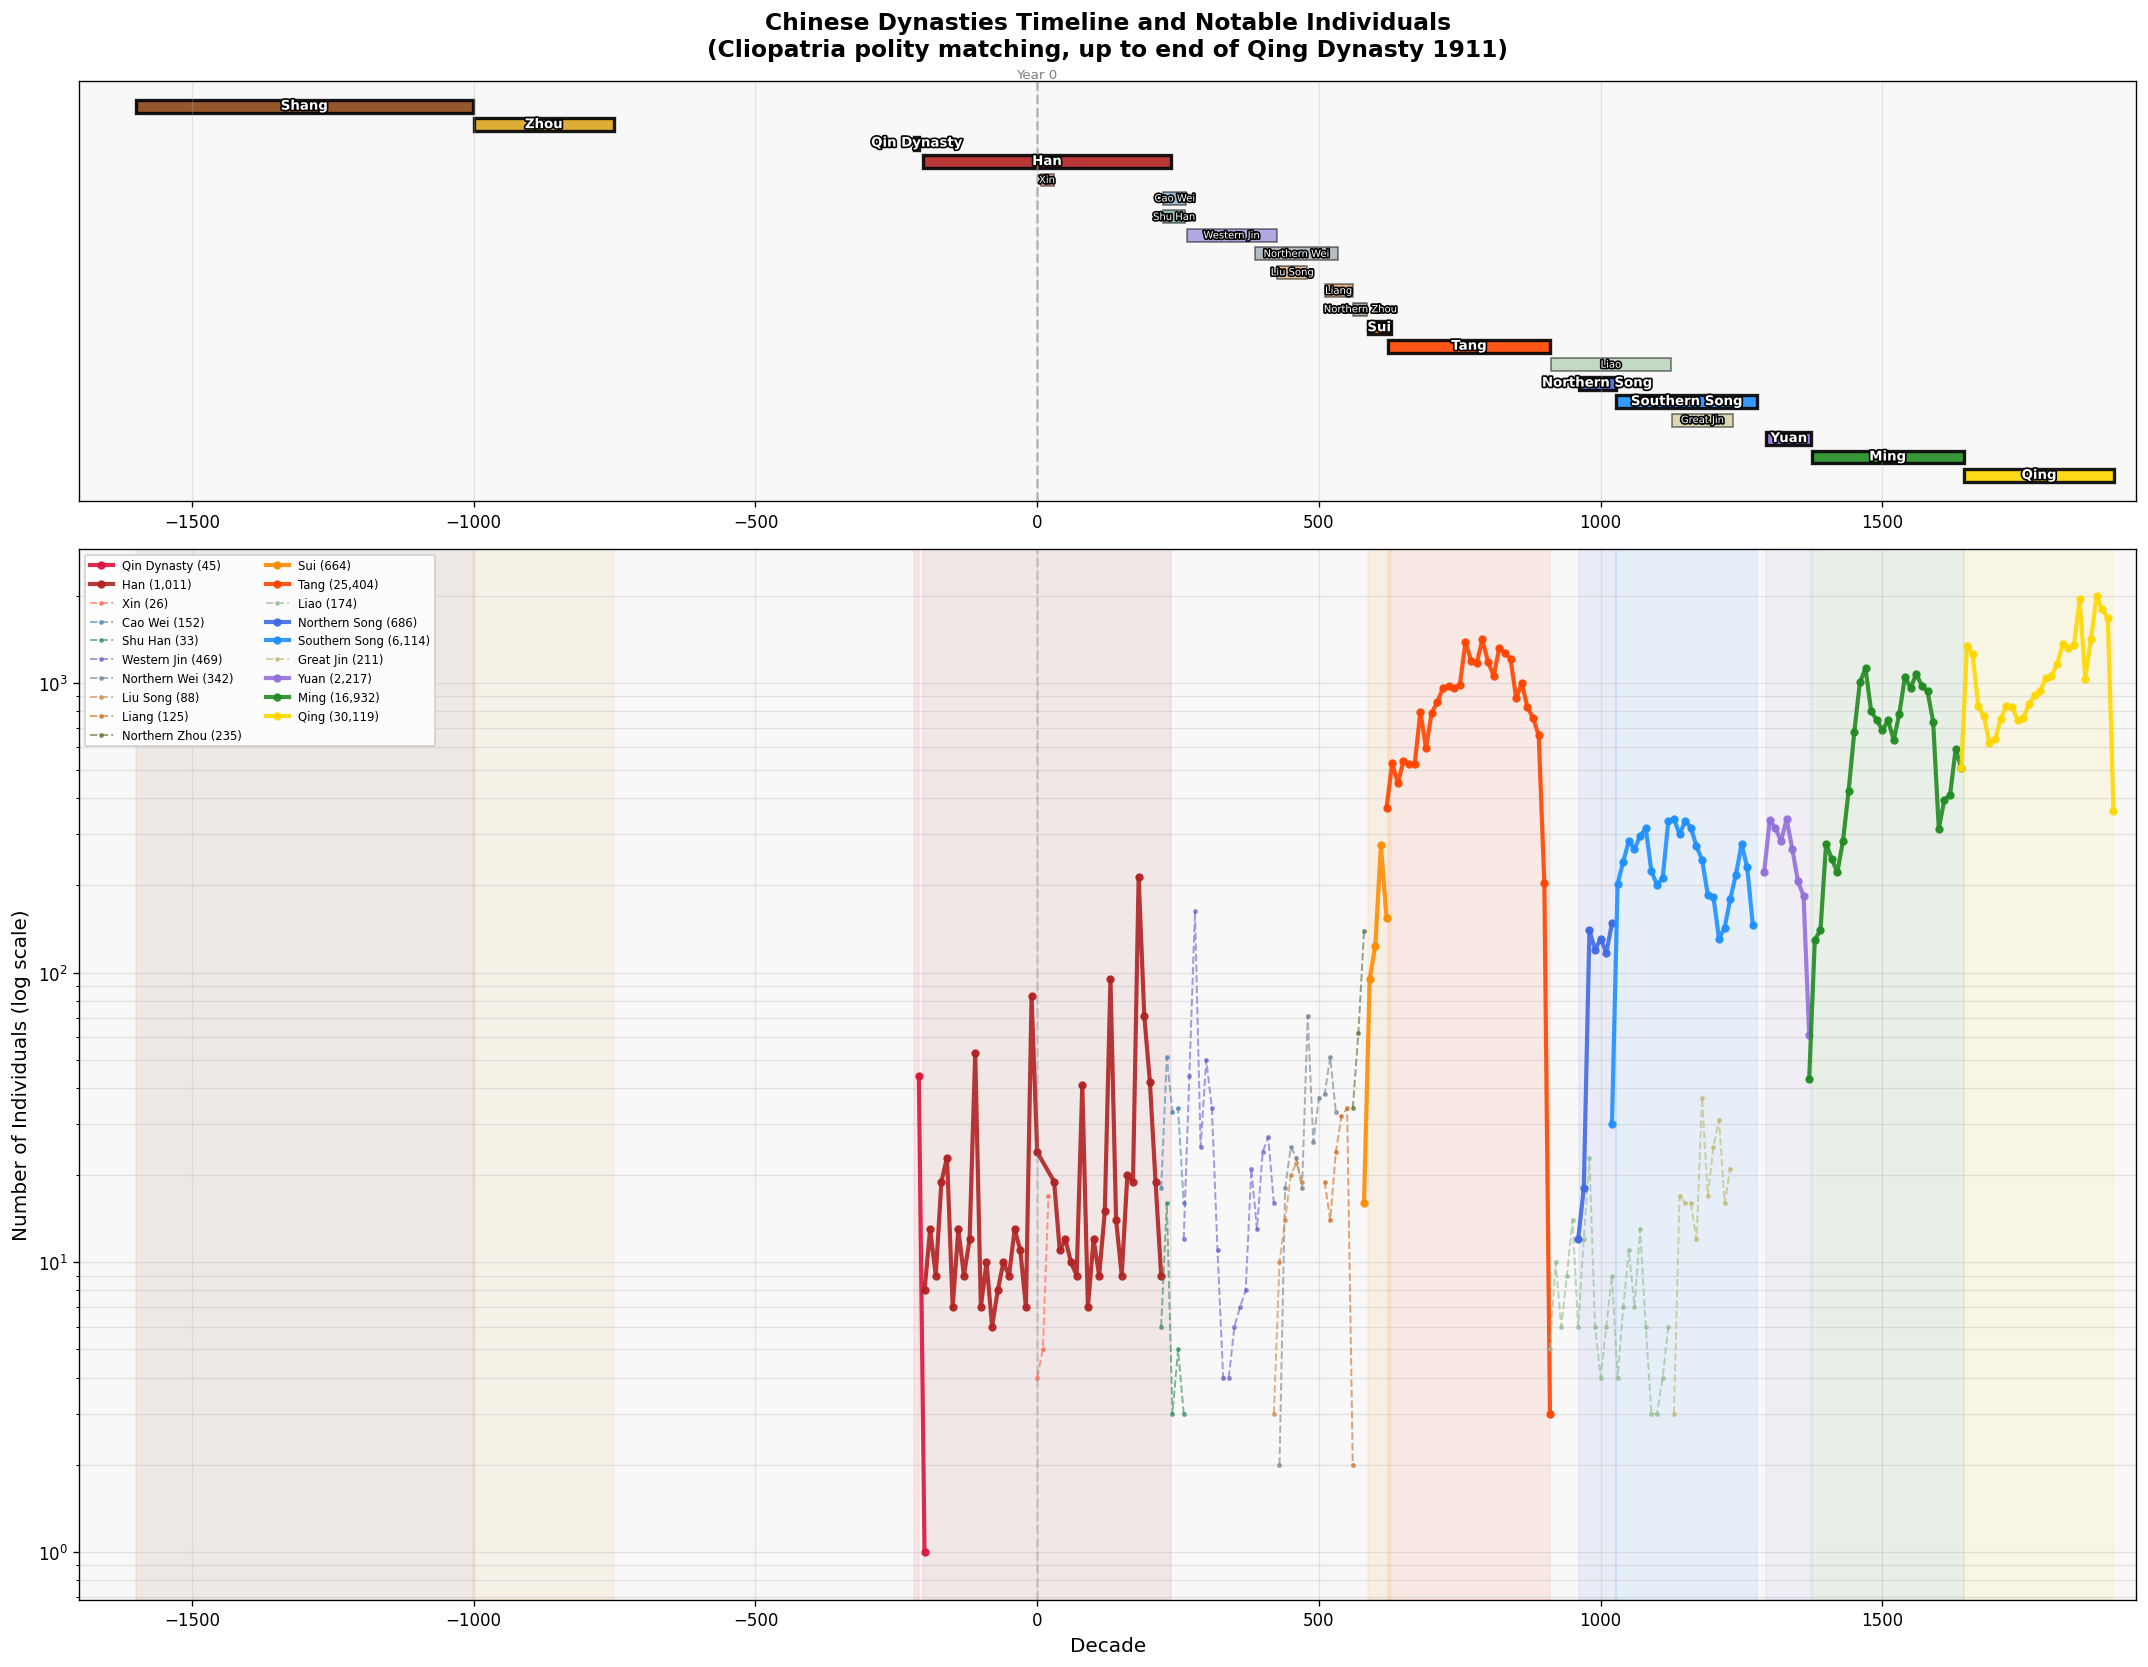

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14),
                                gridspec_kw={'height_ratios': [1, 2.5]})

# --- Top panel: dynasty timeline bars ---
y_pos = 0
for d in dynasty_data:
    width = d['to'] - d['from']
    alpha = 0.9 if d['is_major'] else 0.5
    lw = 2 if d['is_major'] else 1
    ax1.barh(y_pos, width, left=d['from'], height=0.7,
             color=d['color'], alpha=alpha, edgecolor='black', linewidth=lw)
    mid = d['from'] + width / 2
    fs = 8 if d['is_major'] else 6
    fw = 'bold' if d['is_major'] else 'normal'
    ax1.text(mid, y_pos, d['name'], ha='center', va='center',
             fontsize=fs, fontweight=fw, color='white',
             path_effects=[pe.withStroke(linewidth=2, foreground='black')])
    y_pos += 1

ax1.set_yticks([])
ax1.set_title('Chinese Dynasties Timeline and Notable Individuals\n'
              '(Cliopatria polity matching, up to end of Qing Dynasty 1911)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlim(-1700, 1950)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.text(0, -1.5, 'Year 0', ha='center', fontsize=8, color='gray')
ax1.grid(axis='x', alpha=0.3)
ax1.set_facecolor('#f8f8f8')
ax1.invert_yaxis()

# --- Bottom panel: individuals per decade (log scale) ---
for d in dynasty_data:
    if d['total'] < 20:
        continue
    decs = sorted([dec for dec in d['decades'].keys() if -1700 <= dec <= 1920])
    if not decs:
        continue
    counts = [d['decades'].get(dec, 0) for dec in decs]
    lw = 2.5 if d['is_major'] else 1.2
    alpha = 0.9 if d['is_major'] else 0.6
    ls = '-' if d['is_major'] else '--'
    ms = 4 if d['is_major'] else 2
    ax2.plot(decs, counts, color=d['color'], linewidth=lw, alpha=alpha,
             linestyle=ls, marker='o', markersize=ms,
             label=f"{d['name']} ({d['total']:,})")

ax2.set_yscale('log')
ax2.set_xlabel('Decade', fontsize=12)
ax2.set_ylabel('Number of Individuals (log scale)', fontsize=12)
ax2.set_xlim(-1700, 1950)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_facecolor('#f8f8f8')

# Shade major dynasty periods
for d in dynasty_data:
    if d['is_major']:
        ax2.axvspan(d['from'], d['to'], alpha=0.08, color=d['color'])

ax2.legend(fontsize=7, loc='upper left', ncol=2, framealpha=0.9)

plt.tight_layout()
plt.show()

## 3. Stacked area chart (log scale)

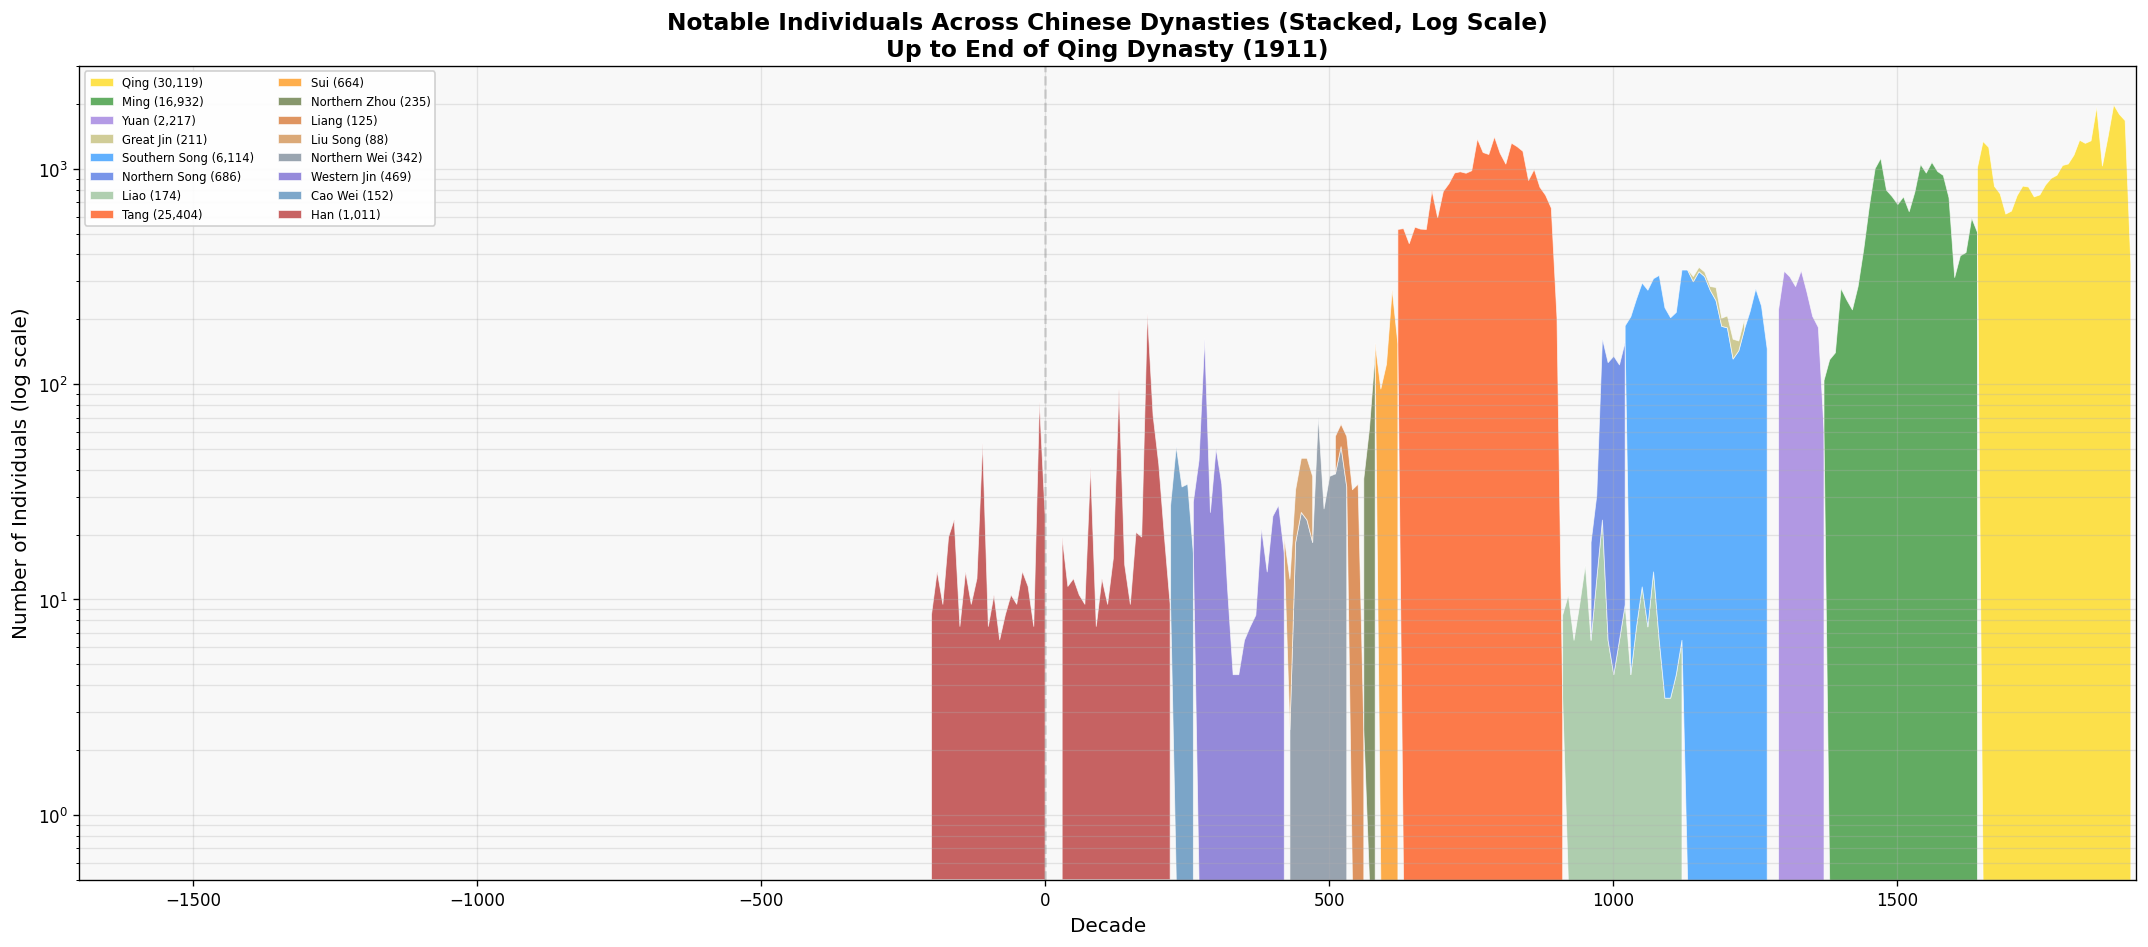

In [5]:
fig, ax = plt.subplots(figsize=(18, 8))

stack_dynasties = [d for d in dynasty_data if d['total'] >= 50]
decade_range = list(range(-1700, 1920, 10))

bottom = np.zeros(len(decade_range))
for d in stack_dynasties:
    counts = np.array([d['decades'].get(dec, 0) for dec in decade_range], dtype=float)
    mask = counts > 0
    if np.any(mask):
        ax.fill_between(decade_range, bottom + 0.5, bottom + counts + 0.5,
                        where=mask, alpha=0.7, color=d['color'],
                        label=f"{d['name']} ({d['total']:,})",
                        linewidth=0.5, edgecolor='white')
    bottom += counts

ax.set_yscale('log')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Number of Individuals (log scale)', fontsize=12)
ax.set_title('Notable Individuals Across Chinese Dynasties (Stacked, Log Scale)\n'
             'Up to End of Qing Dynasty (1911)',
             fontsize=14, fontweight='bold')
ax.set_xlim(-1700, 1920)
ax.set_ylim(0.5, None)
ax.grid(True, alpha=0.3, which='both')
ax.set_facecolor('#f8f8f8')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=7, loc='upper left', ncol=2, framealpha=0.9)

plt.tight_layout()
plt.show()

## 4. Summary table by dynasty

In [6]:
print(f"{'Dynasty':<20s}  {'Period':>16s}  {'Individuals':>12s}  {'Peak Decade':>14s}  {'Peak Count':>11s}")
print('=' * 80)

grand_total = 0
for d in dynasty_data:
    fr_s = f"{abs(d['from'])} BCE" if d['from'] < 0 else f"{d['from']} CE"
    to_s = f"{abs(d['to'])} BCE" if d['to'] < 0 else f"{d['to']} CE"
    period = f"{fr_s} - {to_s}"
    
    if d['decades']:
        peak_dec = max(d['decades'], key=d['decades'].get)
        peak_cnt = d['decades'][peak_dec]
        peak_s = f"{peak_dec}s"
    else:
        peak_s = '-'
        peak_cnt = 0
    
    marker = '*' if d['is_major'] else ' '
    print(f"{marker} {d['name']:<18s}  {period:>16s}  {d['total']:>12,d}  {peak_s:>14s}  {peak_cnt:>11,d}")
    grand_total += d['total']

print('=' * 80)
print(f"  {'TOTAL':<18s}  {'':>16s}  {grand_total:>12,d}")
print(f"\n* = unified/major dynasty")

Dynasty                         Period   Individuals     Peak Decade   Peak Count
* Shang               1600 BCE - 1001 BCE             8          -1030s            2
* Zhou                1000 BCE - 751 BCE            16           -810s            4
* Qin Dynasty         218 BCE - 209 BCE            45           -210s           44
* Han                 202 BCE - 237 CE         1,011            180s          214
  Xin                     6 CE - 29 CE            26             20s           17
  Cao Wei              224 CE - 264 CE           152            230s           51
  Shu Han              224 CE - 262 CE            33            230s           16
  Western Jin          265 CE - 425 CE           469            280s          163
  Northern Wei         387 CE - 533 CE           342            480s           71
  Liu Song             426 CE - 479 CE            88            460s           22
  Liang                510 CE - 560 CE           125            550s           34
  Northern

## 5. Observations

The distribution of notable individuals aligns with known historical patterns:

| Dynasty | Peak Period | Historical Context |
|---------|-----------|--------------------|
| **Tang** (25,404) | 700s-800s CE | Golden age of Chinese poetry and culture |
| **Qing** (30,119) | 1700s-1800s CE | Final imperial dynasty, vast bureaucracy |
| **Ming** (16,932) | 1400s-1500s CE | Cultural renaissance, examination system |
| **Southern Song** (6,114) | 1100s-1200s CE | Neo-Confucian scholarship, printing |
| **Yuan** (2,217) | 1300s CE | Mongol rule, multicultural exchange |
| **Han** (1,011) | 100s-200s CE | Expansion era, Confucian state |

The Tang Dynasty stands out with the highest peak density per decade, reflecting its status as a golden age of Chinese culture. The Qing has the highest absolute count due to its proximity to the modern era and better historical records.

The fragmentation periods (Three Kingdoms, Southern & Northern Dynasties, Five Dynasties & Ten Kingdoms) show lower but non-zero counts, distributed among competing polities.

In [7]:
conn.close()